In [ ]:
!pip install torch_geometric ogb

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv

class VanillaGIN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.5):
        super().__init__()

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        for i in range(num_layers):
            layer_in = in_channels if i == 0 else hidden_channels
            layer_out = hidden_channels 

            mlp = nn.Sequential(
                nn.Linear(layer_in, hidden_channels),
                nn.BatchNorm1d(hidden_channels),
                nn.ReLU(),
                nn.Linear(hidden_channels, layer_out)
            )
            
            self.convs.append(GINConv(mlp, train_eps=True))
            
            if i < num_layers - 1:
                self.bns.append(nn.BatchNorm1d(hidden_channels))

        self.post_lp = nn.Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        for i in range(len(self.convs) - 1):
            x = self.convs[i](x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.convs[-1](x, edge_index)
        return x

In [2]:
from torch_geometric.utils import negative_sampling
from ogb.linkproppred import PygLinkPropPredDataset, Evaluator
import time
import torch

if not hasattr(torch, "_original_load"):
    torch._original_load = torch.load

def _patched_load(f, **kwargs):
    kwargs["weights_only"] = False
    return torch._original_load(f, **kwargs)

torch.load = _patched_load

dataset = PygLinkPropPredDataset(name="ogbl-collab")
split_edge = dataset.get_edge_split()

data = dataset[0]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)

train_edges    = split_edge['train']['edge'].to(device)
val_edges_pos  = split_edge['valid']['edge'].to(device)
val_edges_neg  = split_edge['valid']['edge_neg'].to(device)
test_edges_pos = split_edge['test']['edge'].to(device)
test_edges_neg = split_edge['test']['edge_neg'].to(device)

print(f"val_edges_neg shape:  {val_edges_neg.shape}")
print(f"test_edges_neg shape: {test_edges_neg.shape}")
print(f"Train edges: {train_edges.shape}")
print(f"Val edges: {val_edges_pos.shape}")
print(f"Test edges: {test_edges_pos.shape}")

def score_edges(z, edges):
    return (z[edges[:, 0]] * z[edges[:, 1]]).sum(dim=-1)

Downloaded 0.11 GB: 100%|██████████| 117/117 [00:05<00:00, 22.06it/s]


Extracting dataset/collab.zip


Processing...


Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 43.19it/s]


Converting graphs into PyG objects...


100%|██████████| 1/1 [00:00<00:00, 332.49it/s]

Saving...



Done!


val_edges_neg shape:  torch.Size([100000, 2])
test_edges_neg shape: torch.Size([100000, 2])
Train edges: torch.Size([1179052, 2])
Val edges: torch.Size([60084, 2])
Test edges: torch.Size([46329, 2])


In [14]:
evaluator = Evaluator(name='ogbl-collab')

def train(model, optimizer, criterion):
    model.train()
    optimizer.zero_grad()

    z = model(data.x, data.edge_index)

    pos_score = score_edges(z, train_edges)

    neg_edge_index = negative_sampling(
        edge_index=data.edge_index,
        num_nodes=data.num_nodes,
        num_neg_samples=min(train_edges.size(0), 100000)
    )

    neg_edges = neg_edge_index.t()
    neg_score = score_edges(z, neg_edges)

    scores = torch.cat([pos_score, neg_score])
    labels = torch.cat([
        torch.ones(pos_score.size(0), device=device),
        torch.zeros(neg_score.size(0), device=device)
    ])

    loss = criterion(scores, labels)
    loss.backward()
    optimizer.step()

    return loss.item()

@torch.no_grad()
def evaluate(model):
    model.eval()
    z = model(data.x, data.edge_index)

    results = {}
    for split, pos, neg in [
        ('valid', val_edges_pos, val_edges_neg),
        ('test',  test_edges_pos, test_edges_neg)
    ]:
        pos_score = score_edges(z, pos)
        neg_score = score_edges(z, neg)

        hits = evaluator.eval({
            'y_pred_pos': pos_score,
            'y_pred_neg': neg_score,
        })
        results[split] = hits['hits@50']

    return results

In [32]:
model = VanillaGIN(
    in_channels=dataset.num_features,
    hidden_channels=256,
    num_layers=3,
    dropout=0.5,
    out_channels=256,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = nn.BCEWithLogitsLoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

print(model)
print(f"Num parameters: {sum(p.numel() for p in model.parameters()):,}")

VanillaGIN(
  (convs): ModuleList(
    (0): GINConv(nn=Sequential(
      (0): Linear(in_features=128, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=256, bias=True)
    ))
    (1-2): 2 x GINConv(nn=Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=256, bias=True)
    ))
  )
  (bns): ModuleList(
    (0-1): 2 x BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (post_lp): Linear(in_features=256, out_features=256, bias=True)
)
Num parameters: 430,339


In [33]:
import torch, gc

gc.collect()
torch.cuda.empty_cache()

In [34]:
NUM_EPOCHS = 400
best_val  = 0
best_test = 0

for epoch in range(1, NUM_EPOCHS + 1):
    t = time.time()
    loss = train(model, optimizer, criterion)
    elapsed = time.time() - t
    scheduler.step()

    if epoch % 10 == 0:
        results = evaluate(model)

        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | "
              f"Val Hits@50: {results['valid']:.4f} | "
              f"Test Hits@50: {results['test']:.4f} | "
              f"Time: {elapsed:.2f}s")

        if results['valid'] > best_val:
            best_val  = results['valid']
            best_test = results['test']
            torch.save(model.state_dict(), 'best_gin_vanilla_link.pt')

print(f"\nBest Val  Hits@50: {best_val:.4f}")
print(f"Best Test Hits@50: {best_test:.4f}")

Epoch 010 | Loss: 0.1950 | Val Hits@50: 0.1491 | Test Hits@50: 0.1203 | Time: 0.76s
Epoch 020 | Loss: 0.1681 | Val Hits@50: 0.1394 | Test Hits@50: 0.1100 | Time: 0.76s
Epoch 030 | Loss: 0.1436 | Val Hits@50: 0.1360 | Test Hits@50: 0.1073 | Time: 0.77s
Epoch 040 | Loss: 0.1307 | Val Hits@50: 0.1384 | Test Hits@50: 0.1081 | Time: 0.78s
Epoch 050 | Loss: 0.1216 | Val Hits@50: 0.1126 | Test Hits@50: 0.0786 | Time: 0.77s
Epoch 060 | Loss: 0.1132 | Val Hits@50: 0.1738 | Test Hits@50: 0.1432 | Time: 0.77s
Epoch 070 | Loss: 0.1083 | Val Hits@50: 0.1926 | Test Hits@50: 0.1597 | Time: 0.79s
Epoch 080 | Loss: 0.1040 | Val Hits@50: 0.1866 | Test Hits@50: 0.1538 | Time: 0.77s
Epoch 090 | Loss: 0.1045 | Val Hits@50: 0.1881 | Test Hits@50: 0.1563 | Time: 0.77s
Epoch 100 | Loss: 0.1019 | Val Hits@50: 0.1880 | Test Hits@50: 0.1574 | Time: 0.78s
Epoch 110 | Loss: 0.0984 | Val Hits@50: 0.2290 | Test Hits@50: 0.1973 | Time: 0.78s
Epoch 120 | Loss: 0.0984 | Val Hits@50: 0.2040 | Test Hits@50: 0.1731 | Time

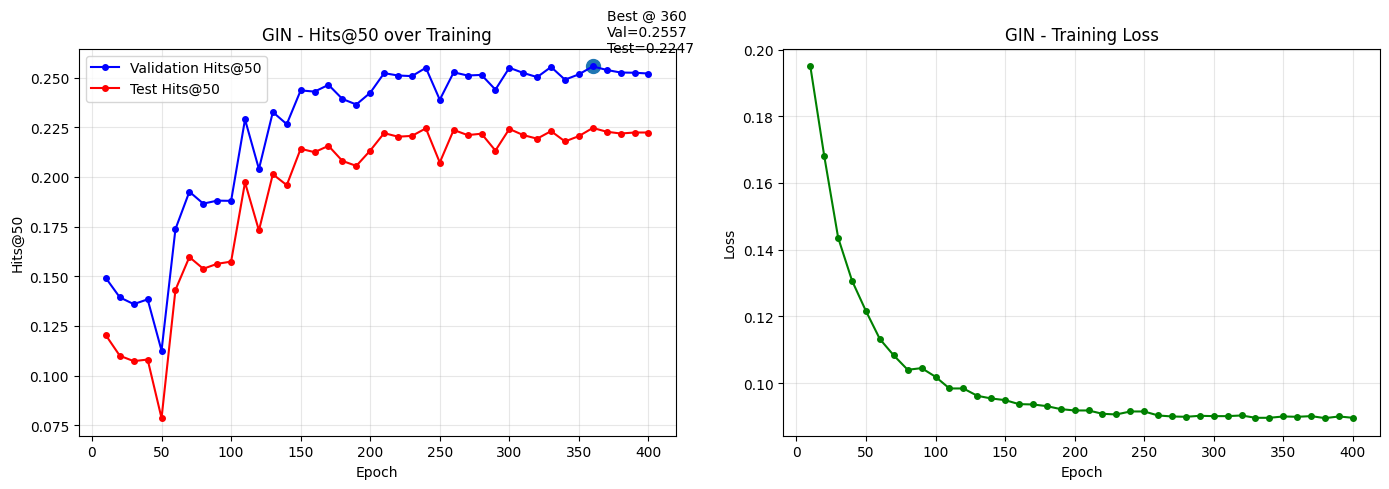

In [35]:
import matplotlib.pyplot as plt

epochs_logged = list(range(10, 401, 10))

val_accs = [
    0.1491, 0.1394, 0.1360, 0.1384, 0.1126,
    0.1738, 0.1926, 0.1866, 0.1881, 0.1880,
    0.2290, 0.2040, 0.2327, 0.2266, 0.2436,
    0.2430, 0.2464, 0.2393, 0.2365, 0.2424,
    0.2523, 0.2511, 0.2508, 0.2550, 0.2389,
    0.2527, 0.2511, 0.2514, 0.2440, 0.2550,
    0.2524, 0.2503, 0.2554, 0.2490, 0.2517,
    0.2557, 0.2539, 0.2526, 0.2525, 0.2521
]

test_accs = [
    0.1203, 0.1100, 0.1073, 0.1081, 0.0786,
    0.1432, 0.1597, 0.1538, 0.1563, 0.1574,
    0.1973, 0.1731, 0.2014, 0.1959, 0.2142,
    0.2125, 0.2157, 0.2081, 0.2056, 0.2133,
    0.2221, 0.2203, 0.2207, 0.2245, 0.2073,
    0.2237, 0.2211, 0.2218, 0.2133, 0.2242,
    0.2211, 0.2193, 0.2231, 0.2179, 0.2206,
    0.2247, 0.2228, 0.2219, 0.2224, 0.2224
]

losses = [
    0.1950, 0.1681, 0.1436, 0.1307, 0.1216,
    0.1132, 0.1083, 0.1040, 0.1045, 0.1019,
    0.0984, 0.0984, 0.0962, 0.0954, 0.0949,
    0.0937, 0.0936, 0.0931, 0.0922, 0.0918,
    0.0918, 0.0908, 0.0906, 0.0915, 0.0915,
    0.0903, 0.0900, 0.0899, 0.0902, 0.0901,
    0.0901, 0.0903, 0.0896, 0.0896, 0.0900,
    0.0899, 0.0901, 0.0895, 0.0900, 0.0896
]

best_idx = val_accs.index(max(val_accs))
best_epoch = epochs_logged[best_idx]
best_val = val_accs[best_idx]
best_test = test_accs[best_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_logged, val_accs, 'b-o', label='Validation Hits@50', markersize=4)
ax1.plot(epochs_logged, test_accs, 'r-o', label='Test Hits@50', markersize=4)

ax1.scatter(best_epoch, best_val, s=100)
ax1.annotate(
    f'Best @ {best_epoch}\nVal={best_val:.4f}\nTest={best_test:.4f}',
    (best_epoch, best_val),
    textcoords="offset points",
    xytext=(10, 10)
)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Hits@50')
ax1.set_title('GIN - Hits@50 over Training')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_logged, losses, 'g-o', markersize=4)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('GIN - Training Loss')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

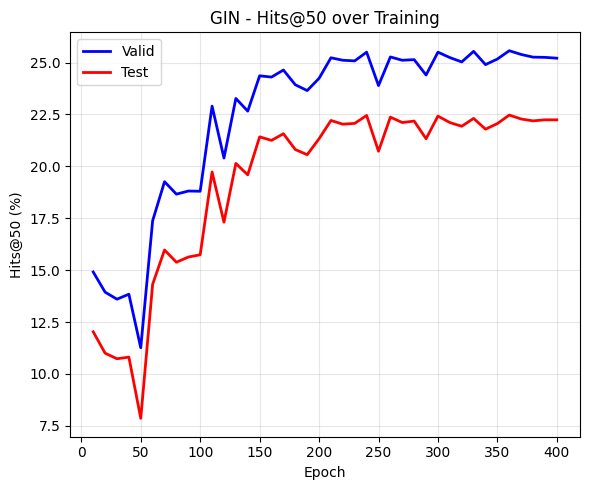

In [36]:
plt.figure(figsize=(6,5))

plt.plot(epochs_logged, [x*100 for x in val_accs], 'b-', label='Valid', linewidth=2)
plt.plot(epochs_logged, [x*100 for x in test_accs], 'r-', label='Test', linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Hits@50 (%)')
plt.title('GIN - Hits@50 over Training')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
@torch.no_grad()
def get_scores_from_embeddings(h, predictor, split_edge, batch_size):
    predictor.eval()

    pos_edge = split_edge['test']['edge'].to(h.device)
    neg_edge = split_edge['test']['edge_neg'].to(h.device)

    pos_scores, neg_scores = [], []

    for perm in DataLoader(range(pos_edge.size(0)), batch_size):
        edge = pos_edge[perm].t()
        pos_scores.append(
            predictor(h[edge[0]], h[edge[1]]).squeeze().cpu()
        )

    for perm in DataLoader(range(neg_edge.size(0)), batch_size):
        edge = neg_edge[perm].t()
        neg_scores.append(
            predictor(h[edge[0]], h[edge[1]]).squeeze().cpu()
        )

    return torch.cat(pos_scores).numpy(), torch.cat(neg_scores).numpy()

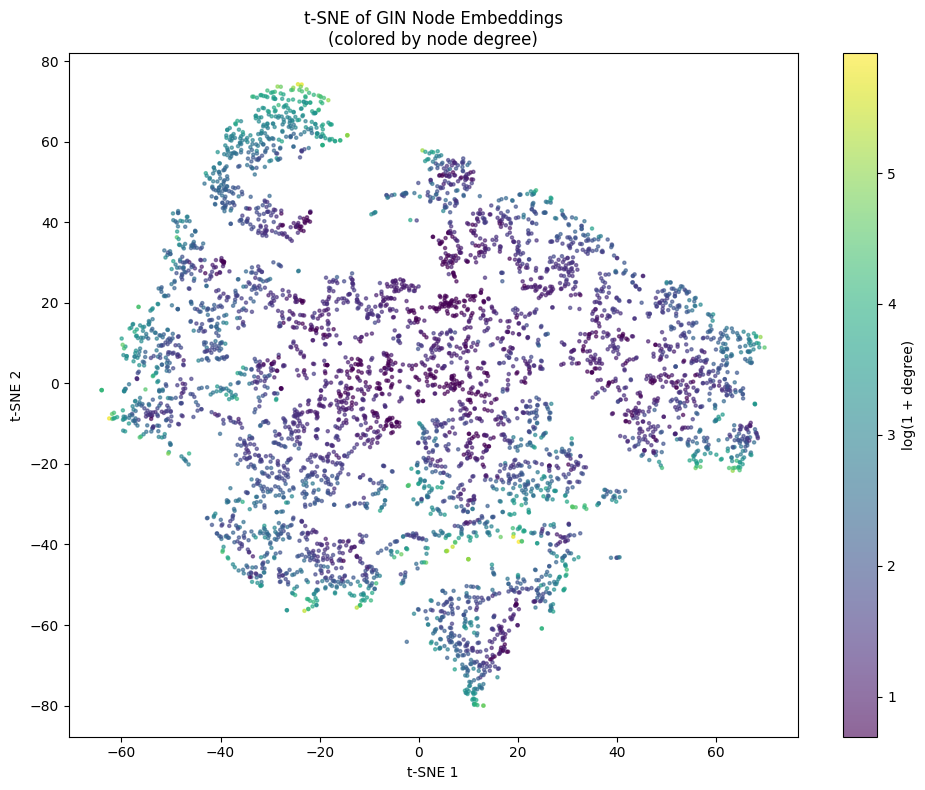

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

if 'embeddings' not in globals() or 'node_idx' not in globals():
    with torch.no_grad():
        model.eval()
        h = model(data.x, data.edge_index)

        num_nodes = min(5000, h.size(0))
        node_idx = torch.randperm(h.size(0))[:num_nodes]

        embeddings = h[node_idx].cpu().numpy()
        node_idx = node_idx.cpu().numpy()

src, dst = data.edge_index.cpu()
deg = torch.zeros(data.num_nodes, dtype=torch.long)
deg.scatter_add_(0, src, torch.ones_like(src))

sampled_degrees = deg[node_idx].numpy()

if 'embeddings_2d' not in globals():
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    embeddings_2d = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=np.log1p(sampled_degrees),
    cmap='viridis',
    s=5,
    alpha=0.6
)

plt.colorbar(scatter, ax=ax, label='log(1 + degree)')
ax.set_title('t-SNE of GIN Node Embeddings\n(colored by node degree)')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')

plt.tight_layout()
plt.savefig('/kaggle/working/tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()